# Tutorial 3h: Cooke Triplet from Scratch

This tutorial walks through an end-to-end optical design workflow to build a Cooke triplet starting from flat parallel plates. 

In professional optical design, rather than starting with a pre-configured geometry, it is common to start with a set of flat glass plates of standard thicknesses and spacing, and then guide the optimizer step-by-step to build curvature, focus, and correct aberrations. 

We will follow this workflow:
1. **Initialize the System**: Setup 3 flat parallel plates of crown (`N-SK16`) and flint (`N-SF5`) glass.
2. **Step 1: Curvature & Seidel Optimization**: Optimize the surface curvatures (using the `reciprocal_radius` variable) to achieve a focal length of 100 mm and minimize third-order Seidel aberrations.
3. **Step 2: RMS Spot Size Optimization**: Refine the system by changing the optimization target to minimize the RMS spot size at all fields.
4. **Step 3: Space (Air Gap) Optimization**: Run a final tight optimization where the air thicknesses between the lenses are also allowed to vary.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optiland import optic, analysis
from optiland.optimization import minimize, OptimizationProblem

## 1. Initial System Setup
We begin with three flat parallel plates. We will use a very large curvature radius ($10^6$ mm) rather than exactly infinity (`np.inf`) to prevent numerical division by zero in the initial paraxial raytracing, while keeping the plates practically flat.

System specifications:
- Aperture: EPD = 20.0 mm ($F/5$ for a target 100 mm EFL)
- Fields: 0, 14, 20 degrees
- Wavelengths: 486.1 nm, 587.6 nm (primary), 656.3 nm
- Materials: N-SK16 (crown) for the outer elements, N-SF5 (flint) for the center element
- Stop is placed on the rear surface of the second element (surface 4)

In [2]:
lens = optic.Optic()

# Object plane
lens.surfaces.add(index=0, thickness=np.inf)

# Three parallel plates
r_init = 1e6
# Element 1: crown N-SK16, thickness 6.0
lens.surfaces.add(index=1, thickness=6.0, radius=r_init, material='N-SK16')
# Air gap 1: thickness 0.5
lens.surfaces.add(index=2, thickness=2.0, radius=-r_init)
# Element 2: flint N-SF5, thickness 2.5
lens.surfaces.add(index=3, thickness=2.5, radius=-r_init, material='N-SF5')
# Air gap 2: thickness 2.0 (with stop)
lens.surfaces.add(index=4, thickness=2.0, radius=r_init, is_stop=True)
# Element 3: crown N-SK16, thickness 2.5
lens.surfaces.add(index=5, thickness=2.5, radius=r_init, material='N-SK16')
# Air gap 3: thickness 0.5
lens.surfaces.add(index=6, thickness=0.5, radius=-r_init)
# Image distance: thickness 55.0
lens.surfaces.add(index=7, thickness=55.0)
# Image plane
lens.surfaces.add(index=8)

# Set aperture and fields
lens.set_aperture(aperture_type='EPD', value=20.0)
lens.fields.set_type('angle')
lens.fields.add(y=0.0)
lens.fields.add(y=14.0)
lens.fields.add(y=20.0)
lens.wavelengths.add(value=0.4861)
lens.wavelengths.add(value=0.5876, is_primary=True)
lens.wavelengths.add(value=0.6563)

print("Starting EFL:", lens.paraxial.f2())

Starting EFL: 880108.1063127919


=== Starting parallel plates design ===


(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

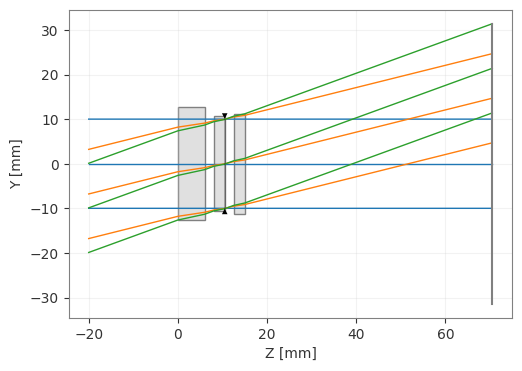

In [3]:
print("=== Starting parallel plates design ===")
lens.draw()

## 2. Step 1: Focal Length and Seidel Optimization
First, we want to optimize for a target focal length of 100 mm and minimize the five primary Seidel aberrations: spherical (SI), coma (SII), astigmatism (SIII), Petzval field curvature (SIV), and distortion (SV).

Since the third-order Seidel aberrations and focal length do not depend on the distance to the image plane, we do not need to vary the image distance (thickness on surface 7) during this optimization step. We vary only the surface curvatures using `reciprocal_radius` on surfaces 1 through 6. This is the inverse of the radius of curvature ($1/\text{radius}$), which allows a smooth transition between convex and concave shapes.

After optimization, we will apply the paraxial image solve to locate the image plane at the new paraxial focus before drawing the intermediate design.

In [4]:
problem1 = OptimizationProblem()

# Target focal length = 100 mm
problem1.add_operand('f2', target=100.0, weight=1.0, input_data={'optic': lens})

# Target all 5 Seidel aberrations to be zero
for i in range(1, 6):
    problem1.add_operand('seidel', target=0.0, weight=1.0, input_data={'optic': lens, 'seidel_number': i})

# Add curvatures of surfaces 1-6 as variables
for s in [1, 2, 3, 4, 5, 6]:
    problem1.add_variable(lens, 'radius', surface_number=s)

print("Number of variables:", len(problem1.variables))
problem1.info()

Number of variables: 6
╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │            7.74414e+11 │                 0 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ f2             │      100 │              │              │        1 │             1 │  880108 │  880008 │            100 │
│  1 │ seidel         │        0 │              │              │        1 │             1 │      -0 │      -0 │              0 │
│  2 │ seidel         │        0 │              │              │        

In [5]:
# Run DLS optimization
result1 = minimize(problem1, 'dls', maxiter=150)
print(result1)

Optimization started — initial merit = 7.74414e+11
  iter     1 | merit = 1.57199e+11
  iter     2 | merit = 2.63019e+10
  iter     3 | merit = 3.40542e+09
  iter     4 | merit = 3.84004e+08
  iter     5 | merit = 1.51311
  iter     6 | merit = 0.0397506
  iter     7 | merit = 0.026492
  iter     8 | merit = 0.0261915
  iter     9 | merit = 0.0261746
Optimization ended  — final merit = 0.0261746  (+100.00%)  [cost_tol=1.00e-03 (rel_change=6.45e-04)]
OptimizationResult(x=array([ 1.45781906e+00, -3.66079585e+00, -4.76261071e+06,  4.76318228e+06,
        1.29758500e+00, -3.30585958e+00]), success=True, status='cost_tol=1.00e-03 (rel_change=6.45e-04)', value=0.02617456603724341, initial_value=774414267176.2261, improvement_pct=99.99999999999662, iterations=9, n_value_evals=17, n_jac_evals=9, wall_time_s=2.3992143999930704, history=None, backend='numpy', method='dls', resolved_from=None, multipliers=None, active_set=None, constraint_report=None, max_constraint_violation=None, grad_norm=0.09

In [6]:
# Apply paraxial image solve to update the image distance (thickness 7)
lens.updater.image_solve()

print("Step 1 EFL after image solve:", lens.paraxial.f2())
print("Step 1 Image distance:", lens.surfaces[7].thickness)
print("Step 1 Seidels:", lens.aberrations.seidels())

Step 1 EFL after image solve: 99.99526121494888
Step 1 Image distance: 94.75723541560916
Step 1 Seidels: [-0.01659203  0.04552423 -0.12897311 -0.08377067  0.01236002]


=== Design after Seidel optimization ===


(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

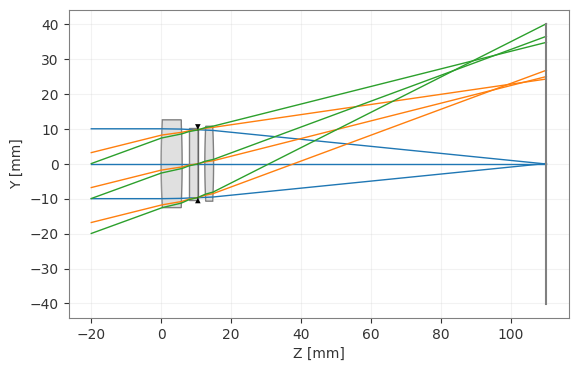

In [7]:
print("=== Design after Seidel optimization ===")
lens.draw()

Let's see what the spot diagram of this intermediate Seidel-optimized design looks like. Since Seidel aberrations are third-order approximations, the real ray performance (RMS spot size) is still not fully optimized.

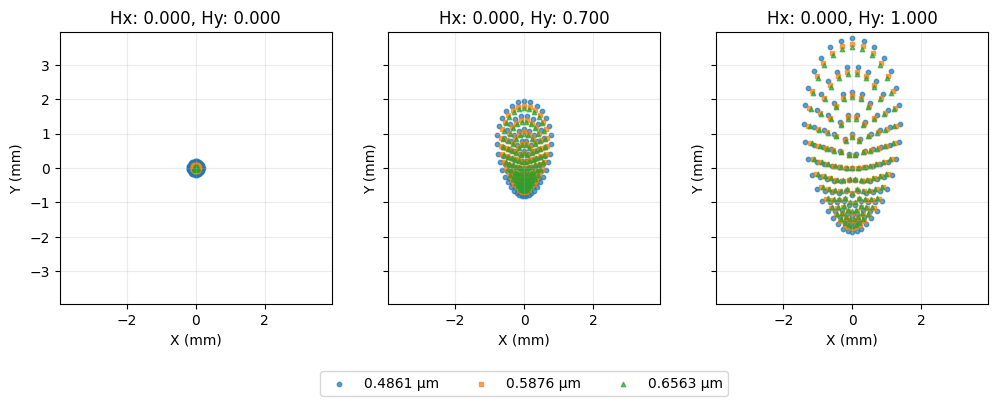

(<Figure size 1200x400 with 3 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.700'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 1.000'}, xlabel='X (mm)', ylabel='Y (mm)'>])

In [8]:
spot_step1 = analysis.SpotDiagram(lens)
spot_step1.view()

## 3. Step 2: RMS Spot Size Optimization
Now we want to directly optimize the real ray performance. We replace the Seidel operands with RMS spot size operands across all fields. Since the spot size depends heavily on the image plane location, we now include the image distance (thickness 7) as an optimization variable along with the curvatures.

In [9]:
problem2 = OptimizationProblem()

# Target focal length = 100 mm
problem2.add_operand('f2', target=100.0, weight=1.0, input_data={'optic': lens})

# Minimize RMS spot size at each field coordinate
for Hx, Hy in lens.fields.get_field_coords():
    input_data = {
        'optic': lens,
        'surface_number': -1,
        'Hx': Hx,
        'Hy': Hy,
        'num_rays': 5,
        'wavelength': 0.5876,
        'distribution': 'hexapolar',
    }
    problem2.add_operand('rms_spot_size', target=0.0, weight=1.0, input_data=input_data)

# Variables: curvatures (surfaces 1-6) and image distance (thickness 7)
for s in [1, 2, 3, 4, 5, 6]:
    problem2.add_variable(lens, 'reciprocal_radius', surface_number=s)
problem2.add_variable(lens, 'thickness', surface_number=7)

problem2.info()

╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │                3.07488 │                 0 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ f2             │      100 │              │              │        1 │             1 │  99.995 │  -0.005 │           0    │
│  1 │ rms spot size  │        0 │              │              │        1 │             1 │   0.054 │   0.054 │           0.09 │
│  2 │ rms spot size  │        0 │              │              │        1 │             1 │   0

In [10]:
# Run optimization
result2 = minimize(problem2, 'dls', maxiter=150)
print(result2)

Optimization started — initial merit = 3.07488
  iter     1 | merit = 1.24654
  iter     2 | merit = 1.20308
  iter     3 | merit = 1.15188
  iter     4 | merit = 1.113
  iter     5 | merit = 1.07232
  iter     6 | merit = 1.02605
  iter     7 | merit = 0.946479
  iter     8 | merit = 0.884126
  iter     9 | merit = 0.789872
  iter    10 | merit = 0.724385
  iter    11 | merit = 0.616863
  iter    12 | merit = 0.464199
  iter    13 | merit = 0.435534
  iter    14 | merit = 0.385275
  iter    15 | merit = 0.363468
  iter    16 | merit = 0.349997
  iter    17 | merit = 0.326848
  iter    18 | merit = 0.312539
  iter    19 | merit = 0.307049
  iter    20 | merit = 0.298012
  iter    21 | merit = 0.293153
  iter    22 | merit = 0.286124
  iter    23 | merit = 0.282108
  iter    24 | merit = 0.275967
  iter    25 | merit = 0.272804
  iter    26 | merit = 0.267209
  iter    27 | merit = 0.264954
  iter    28 | merit = 0.259867
  iter    29 | merit = 0.258421
  iter    30 | merit = 0.254078
 

In [11]:
print("Step 2 EFL:", lens.paraxial.f2())
print("Step 2 Image distance:", lens.surfaces[7].thickness)

Step 2 EFL: 100.00090275468982
Step 2 Image distance: 88.60372244882936


=== Design after RMS spot size optimization ===


(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

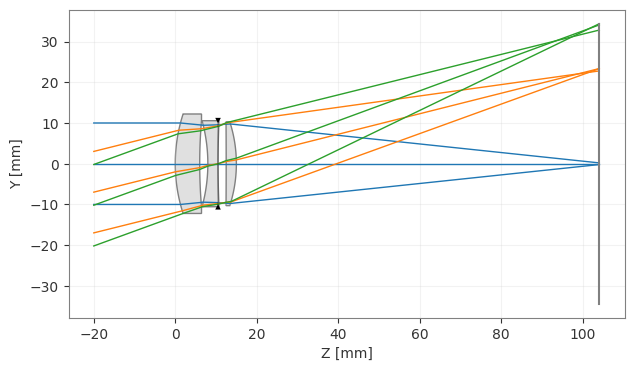

In [12]:
print("=== Design after RMS spot size optimization ===")
lens.draw()

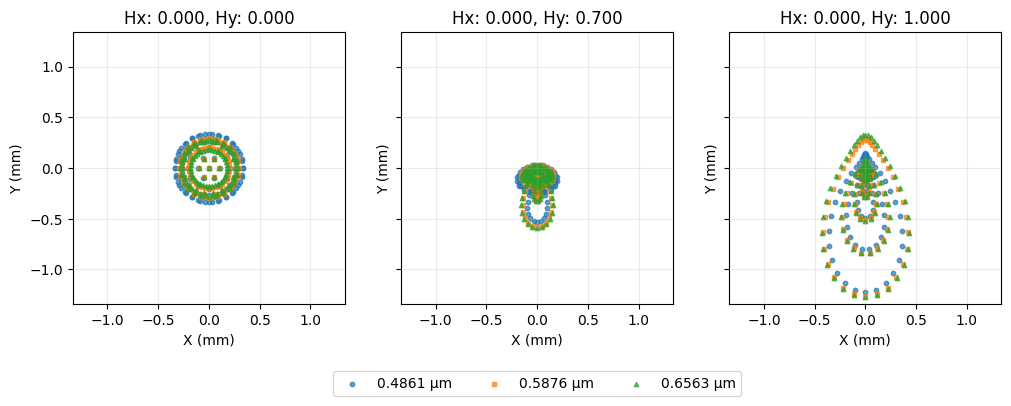

(<Figure size 1200x400 with 3 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.700'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 1.000'}, xlabel='X (mm)', ylabel='Y (mm)'>])

In [13]:
spot_step2 = analysis.SpotDiagram(lens)
spot_step2.view()

## 4. Step 3: Final Optimization (Varying Air Thicknesses)
To achieve a very good design, we will allow the air gaps between the lenses to vary. This provides the optimizer with additional degrees of freedom to minimize aberrations.

Our variables are now:
- Curvatures: surfaces 1-6 (`reciprocal_radius`)
- Air gaps: surfaces 2, 4, and 6 (`thickness`)
- Image distance: surface 7 (`thickness`)

We run a tight optimization with a higher iteration count to ensure we get a well-converged, high-quality lens.

In [14]:
problem3 = OptimizationProblem()

# Target focal length = 100 mm
problem3.add_operand('f2', target=100.0, weight=1.0, input_data={'optic': lens})

# Minimize RMS spot size at each field coordinate
for Hx, Hy in lens.fields.get_field_coords():
    input_data = {
        'optic': lens,
        'surface_number': -1,
        'Hx': Hx,
        'Hy': Hy,
        'num_rays': 5,
        'wavelength': 0.5876,
        'distribution': 'hexapolar',
    }
    problem3.add_operand('rms_spot_size', target=0.0, weight=1.0, input_data=input_data)

# Variables: curvatures, image distance, and air gaps
for s in [1, 2, 3, 4, 5, 6]:
    problem3.add_variable(lens, 'reciprocal_radius', surface_number=s)
for s in [2, 4, 6]:
    problem3.add_variable(lens, 'thickness', surface_number=s, min_val=0.1, max_val=20.0)
problem3.add_variable(lens, 'thickness', surface_number=7, min_val=40.0, max_val=120.0)

problem3.info()

╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │               0.249825 │                 0 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ f2             │      100 │              │              │        1 │             1 │ 100.001 │   0.001 │           0    │
│  1 │ rms spot size  │        0 │              │              │        1 │             1 │   0.245 │   0.245 │          23.95 │
│  2 │ rms spot size  │        0 │              │              │        1 │             1 │   0

In [15]:
# Run a tight optimization
result3 = minimize(problem3, 'dls', maxiter=300, tol=1e-10)
print(result3)

Optimization started — initial merit = 0.249825
  iter     1 | merit = 0.0749941
  iter     2 | merit = 0.0717314
  iter     3 | merit = 0.0674835
  iter     4 | merit = 0.0662238
  iter     5 | merit = 0.0662005
  iter     6 | merit = 0.0659617
  iter     7 | merit = 0.0658579
  iter     8 | merit = 0.0658137
  iter     9 | merit = 0.0657468
  iter    10 | merit = 0.0655976
  iter    11 | merit = 0.0655385
  iter    12 | merit = 0.0654411
  iter    13 | merit = 0.0654074
  iter    14 | merit = 0.0652493
  iter    15 | merit = 0.0651932
  iter    16 | merit = 0.0651476
  iter    17 | merit = 0.0650353
  iter    18 | merit = 0.0649591
  iter    19 | merit = 0.0648405
  iter    20 | merit = 0.0647
  iter    21 | merit = 0.0645739
  iter    22 | merit = 0.0644153
  iter    23 | merit = 0.0643022
  iter    24 | merit = 0.0640552
  iter    25 | merit = 0.0639762
  iter    26 | merit = 0.0639279
  iter    27 | merit = 0.0638326
  iter    28 | merit = 0.0637773
  iter    29 | merit = 0.063718

In [16]:
print("Step 3 EFL:", lens.paraxial.f2())
print("Step 3 air spaces [2, 4, 6] and image distance [7]:")
print([lens.surfaces[s].thickness for s in [2, 4, 6, 7]])

Step 3 EFL: 99.99992600946645
Step 3 air spaces [2, 4, 6] and image distance [7]:
[np.float64(17.77189211732761), np.float64(1.8182128052191016), np.float64(0.10000000000000009), np.float64(73.3039709762098)]


=== Final optimized Cooke triplet design ===


(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

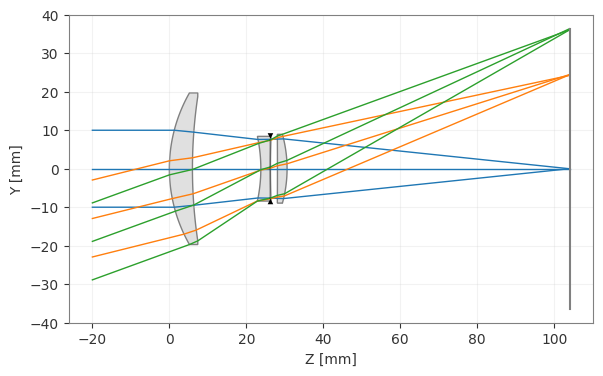

In [17]:
print("=== Final optimized Cooke triplet design ===")
lens.draw()

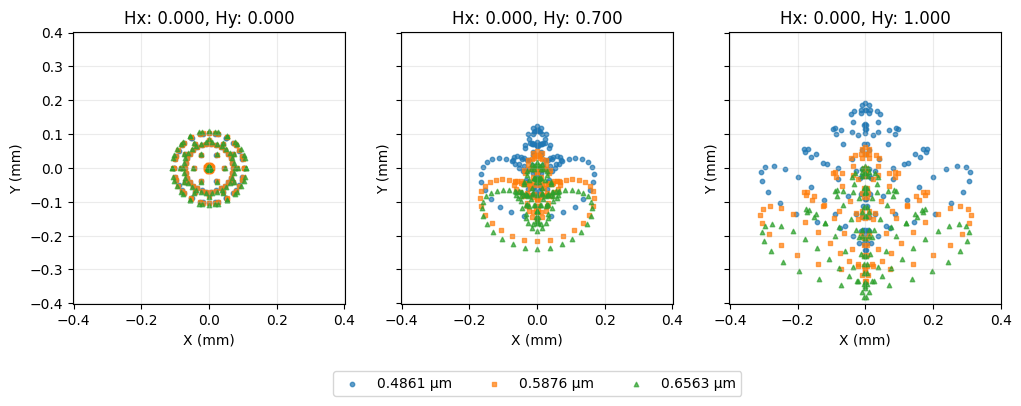

(<Figure size 1200x400 with 3 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.700'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 1.000'}, xlabel='X (mm)', ylabel='Y (mm)'>])

In [18]:
spot_step3 = analysis.SpotDiagram(lens)
spot_step3.view()

In [19]:
# Print RMS spot radii comparison at each stage
fields = lens.fields.get_field_coords()

rms_step1 = spot_step1.rms_spot_radius()
rms_step2 = spot_step2.rms_spot_radius()
rms_step3 = spot_step3.rms_spot_radius()

print('RMS spot radius comparison (mm):')
print(f'{"Field":>12}  {"Seidel Stage":>15}  {"RMS Stage":>15}  {"Final Stage":>15}')
for i, field in enumerate(fields):
    r1 = rms_step1[i][0] # primary wavelength index 0
    r2 = rms_step2[i][0]
    r3 = rms_step3[i][0]
    print(f'{str(field):>12}  {r1:>15.5f}  {r2:>15.5f}  {r3:>15.5f}')

RMS spot radius comparison (mm):
       Field     Seidel Stage        RMS Stage      Final Stage
  (0.0, 0.0)          0.13647          0.29184          0.07338
  (0.0, 0.7)          1.08941          1.25333          0.08979
  (0.0, 1.0)          1.71495          2.55933          0.17088


## Conclusions
- Starting from three flat parallel plates, we optimized a Cooke triplet step-by-step.
- Optimizing for focal length and Seidel aberrations first bends the flat plates into a recognizable triplet shape, correcting the primary aberrations.
- Applying `lens.updater.image_solve()` automatically sets the image plane at the paraxial focus.
- Changing the merit function to minimize the RMS spot size refines the curvatures to significantly improve real ray imaging performance.
- Allowing the air gaps between the lenses to vary in the final tight optimization provides the extra degrees of freedom needed to make this a high-quality F/5 lens.